In [39]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor,ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib


In [40]:
os.getcwd() #Checking current working directory

'C:\\Users\\User\\Downloads'

In [41]:
#loading from csv file and glancing at the data
data=pd.read_csv('youtube_ad_revenue_dataset.csv')
data.head()

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [42]:
data.shape  #Checking for shape

(122400, 12)

In [43]:
data.dtypes

video_id                 object
date                     object
views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
dtype: object

In [44]:
data.duplicated().sum() #checking for duplicated columns

np.int64(2400)

In [45]:
data=data.drop_duplicates()

In [46]:
data.duplicated().sum() #checking for duplicated columns

np.int64(0)

In [47]:
data.isnull().sum() #Checking for null values

video_id                   0
date                       0
views                      0
likes                   6000
comments                6000
watch_time_minutes      6000
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [48]:
data['likes'] = data['likes'].fillna(data['likes'].mean())
data['comments'] = data['comments'].fillna(data['comments'].mean())
data['watch_time_minutes'] = data['watch_time_minutes'].fillna(data['watch_time_minutes'].mean())

In [49]:
data.isnull().sum() #Ensuring there are no null values

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64

In [50]:
data['date'] = pd.to_datetime(data['date'])

In [51]:
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day
data['day_of_week'] = data['date'].dt.dayofweek

data.drop(columns='date',inplace=True) #dropped date col after extracting the values 

In [52]:
data['engagement_rate'] = (data['likes'] + data['comments']) / data['views']
data.head()

,video_id,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,year,month,day,day_of_week,engagement_rate
0,vid_3092,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,2024,9,24,1,0.155093
1,vid_3459,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,2024,9,22,6,0.098632
2,vid_4784,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,2024,11,21,3,0.214519
3,vid_4078,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261,2025,1,28,1,0.142814
4,vid_3522,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388,2025,4,28,0,0.236121


In [53]:
data.info() #Checking for data types and non null values

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              120000 non-null  object 
 1   views                 120000 non-null  int64  
 2   likes                 120000 non-null  float64
 3   comments              120000 non-null  float64
 4   watch_time_minutes    120000 non-null  float64
 5   video_length_minutes  120000 non-null  float64
 6   subscribers           120000 non-null  int64  
 7   category              120000 non-null  object 
 8   device                120000 non-null  object 
 9   country               120000 non-null  object 
 10  ad_revenue_usd        120000 non-null  float64
 11  year                  120000 non-null  int32  
 12  month                 120000 non-null  int32  
 13  day                   120000 non-null  int32  
 14  day_of_week           120000 non-null  int32  
 15  engag

Univariate Analysis for Numerical Columns in data:


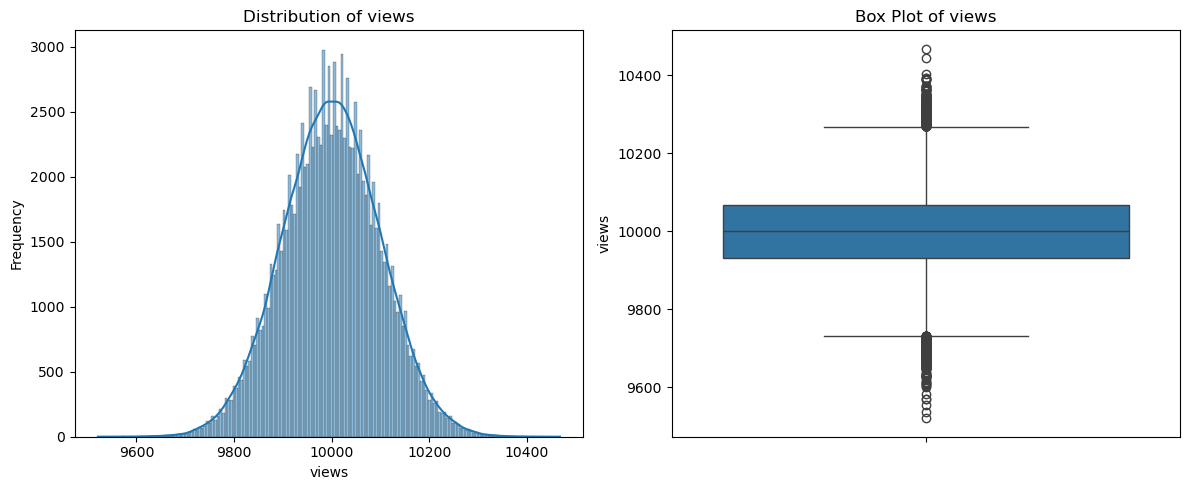

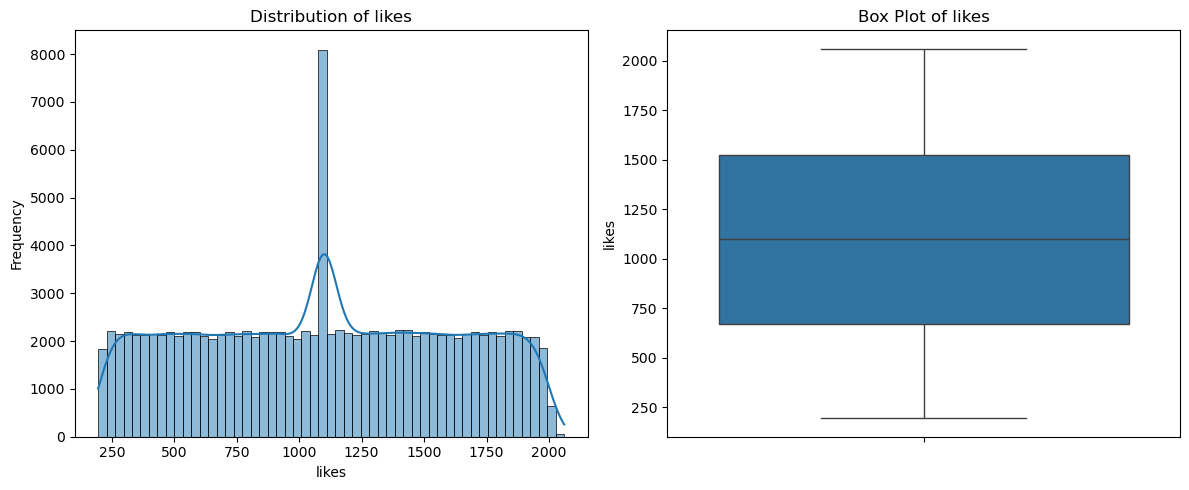

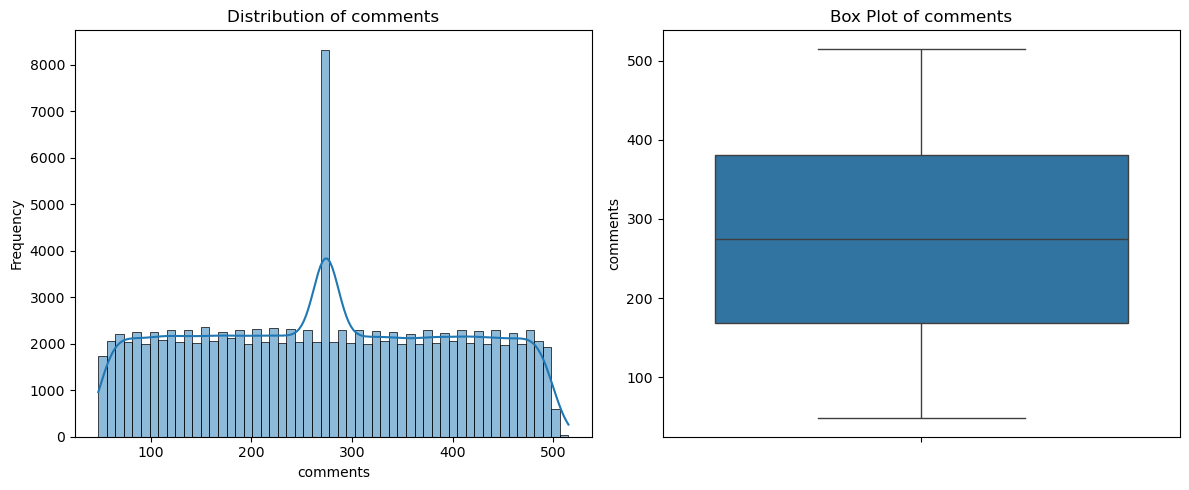

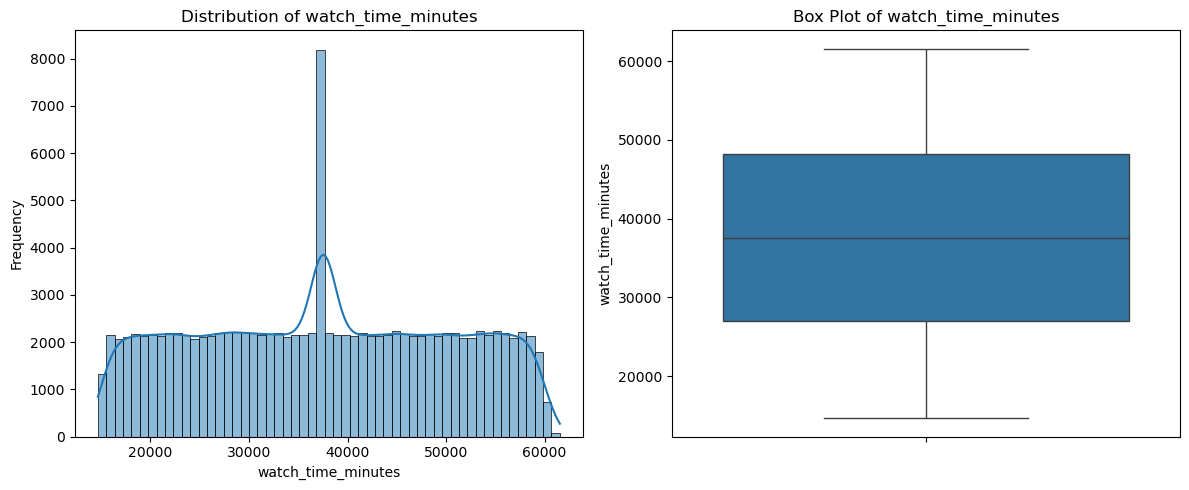

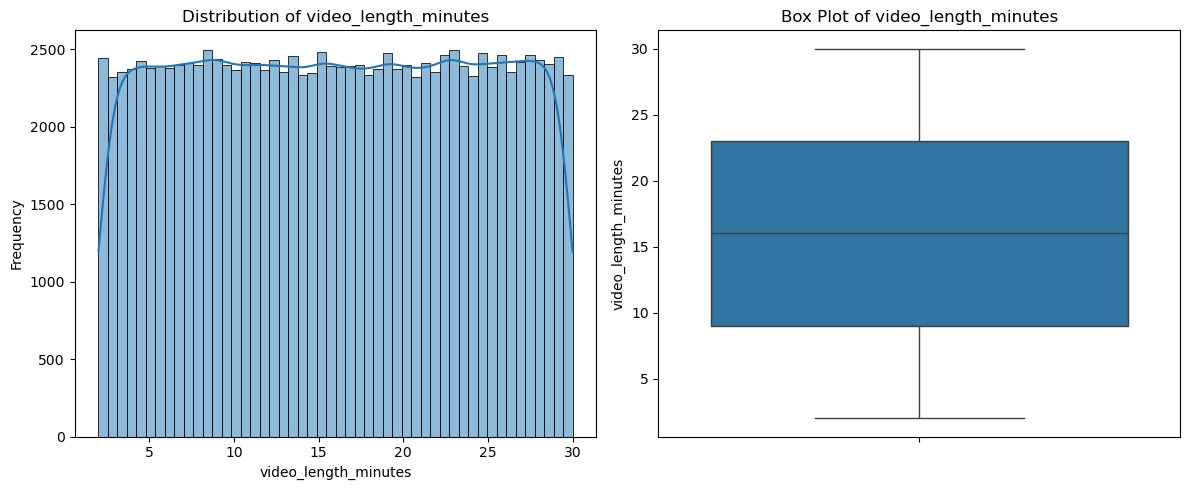

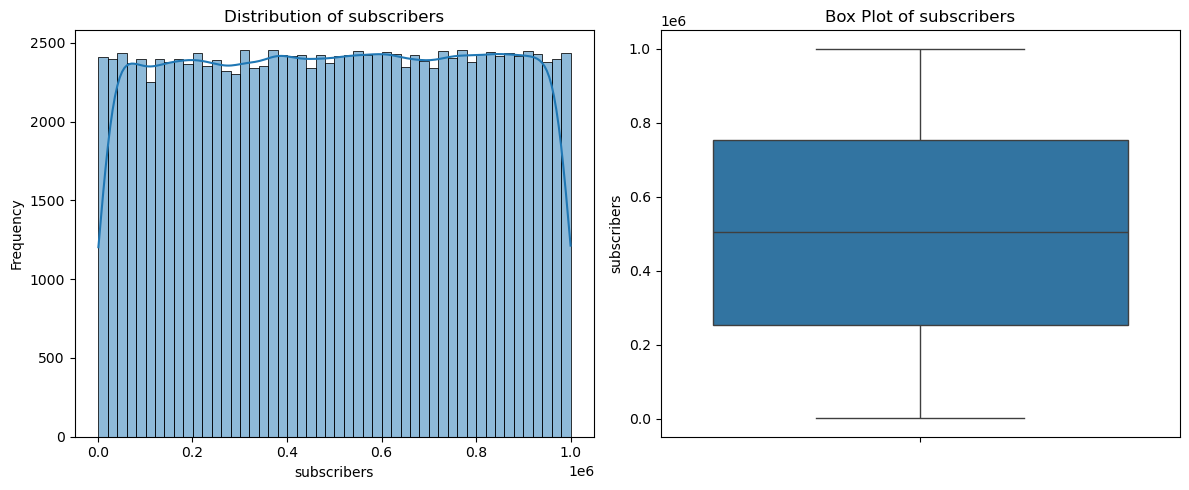

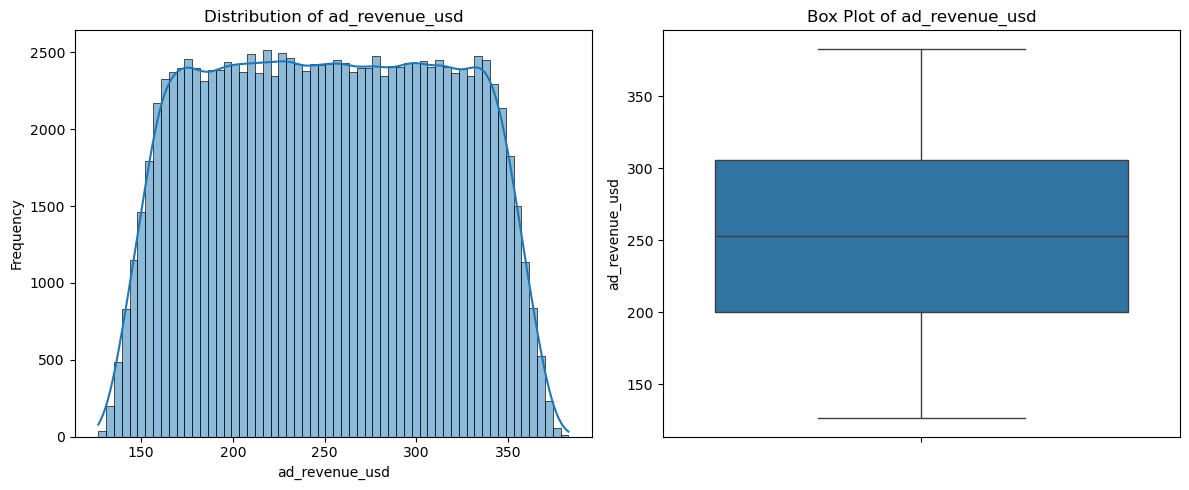

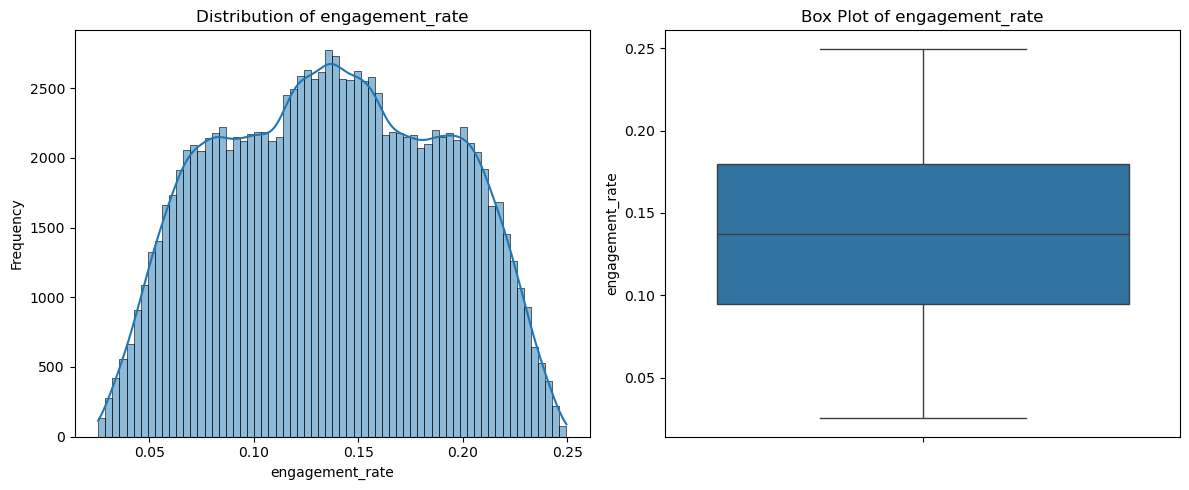

In [54]:
# Univariate Analysis for Numerical Columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

print("Univariate Analysis for Numerical Columns in data:")
for col in numerical_cols:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Box plot
    plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
    sns.boxplot(y=data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

In [55]:
data_encoded = pd.get_dummies(data, columns=['category', 'device', 'country'], drop_first=True)
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   video_id                120000 non-null  object 
 1   views                   120000 non-null  int64  
 2   likes                   120000 non-null  float64
 3   comments                120000 non-null  float64
 4   watch_time_minutes      120000 non-null  float64
 5   video_length_minutes    120000 non-null  float64
 6   subscribers             120000 non-null  int64  
 7   ad_revenue_usd          120000 non-null  float64
 8   year                    120000 non-null  int32  
 9   month                   120000 non-null  int32  
 10  day                     120000 non-null  int32  
 11  day_of_week             120000 non-null  int32  
 12  engagement_rate         120000 non-null  float64
 13  category_Entertainment  120000 non-null  bool   
 14  category_Gaming         1

In [56]:
data_encoded = data_encoded.drop(columns='video_id')

In [57]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   views                   120000 non-null  int64  
 1   likes                   120000 non-null  float64
 2   comments                120000 non-null  float64
 3   watch_time_minutes      120000 non-null  float64
 4   video_length_minutes    120000 non-null  float64
 5   subscribers             120000 non-null  int64  
 6   ad_revenue_usd          120000 non-null  float64
 7   year                    120000 non-null  int32  
 8   month                   120000 non-null  int32  
 9   day                     120000 non-null  int32  
 10  day_of_week             120000 non-null  int32  
 11  engagement_rate         120000 non-null  float64
 12  category_Entertainment  120000 non-null  bool   
 13  category_Gaming         120000 non-null  bool   
 14  category_Lifestyle      1

In [58]:


# Identify numerical columns for scaling
numerical_cols_to_scale = data_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

#Excluding the target variable 'ad_revenue_usd' from feature scaling
if 'ad_revenue_usd' in numerical_cols_to_scale:
    numerical_cols_to_scale.remove('ad_revenue_usd')

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the selected numerical columns
data_encoded[numerical_cols_to_scale] = scaler.fit_transform(data_encoded[numerical_cols_to_scale])

print("Numerical columns standardized using StandardScaler (excluding target variable).")
data_encoded.head()

Numerical columns standardized using StandardScaler (excluding target variable).


,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,year,month,day,...,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US
0,-0.638847,0.239775,0.360982,-0.872393,-1.627204,-0.950903,203.178237,2024,9,24,...,False,False,False,True,False,False,False,True,False,False
1,0.171818,-0.903658,0.566579,-1.764055,0.954887,0.810515,140.880508,2024,9,22,...,False,False,False,False,True,True,False,False,False,False
2,0.972474,1.736705,-0.690726,1.563477,1.259475,-0.907735,360.134008,2024,11,21,...,False,False,False,True,False,True,False,False,False,False
3,0.341957,0.180530,-0.255809,-0.490266,-0.525371,-0.235154,224.638261,2025,1,28,...,False,False,True,False,False,False,False,False,True,False
4,-1.109233,1.497749,1.602472,-1.728039,-1.160443,-1.596116,165.514388,2025,4,28,...,False,False,True,False,False,True,False,False,False,False


In [59]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   views                   120000 non-null  float64
 1   likes                   120000 non-null  float64
 2   comments                120000 non-null  float64
 3   watch_time_minutes      120000 non-null  float64
 4   video_length_minutes    120000 non-null  float64
 5   subscribers             120000 non-null  float64
 6   ad_revenue_usd          120000 non-null  float64
 7   year                    120000 non-null  int32  
 8   month                   120000 non-null  int32  
 9   day                     120000 non-null  int32  
 10  day_of_week             120000 non-null  int32  
 11  engagement_rate         120000 non-null  float64
 12  category_Entertainment  120000 non-null  bool   
 13  category_Gaming         120000 non-null  bool   
 14  category_Lifestyle      1

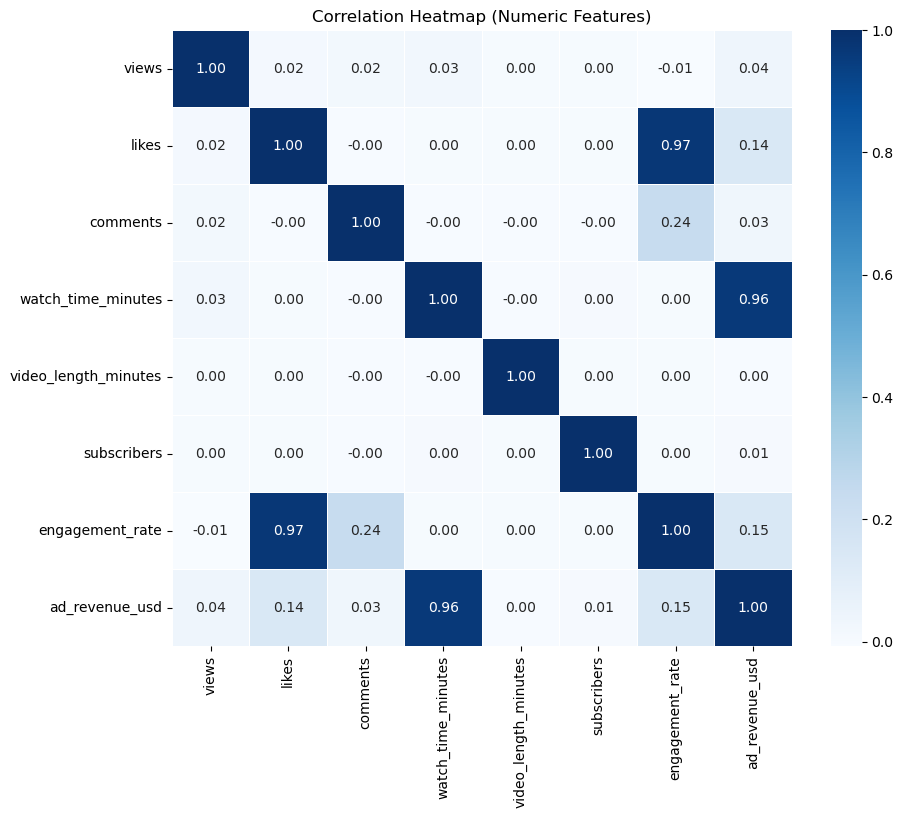

In [60]:
# Calculate the correlation matrix for the encoded and standardized data
numeric_cols = [
    'views',
    'likes',
    'comments',
    'watch_time_minutes',
    'video_length_minutes',
    'subscribers',
    'engagement_rate'
]
corr = data_encoded.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data_encoded[numeric_cols + ['ad_revenue_usd']].corr(), cmap='Blues',annot=True, fmt='.2f', linewidths=.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [61]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120000 entries, 0 to 122399
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   views                   120000 non-null  float64
 1   likes                   120000 non-null  float64
 2   comments                120000 non-null  float64
 3   watch_time_minutes      120000 non-null  float64
 4   video_length_minutes    120000 non-null  float64
 5   subscribers             120000 non-null  float64
 6   ad_revenue_usd          120000 non-null  float64
 7   year                    120000 non-null  int32  
 8   month                   120000 non-null  int32  
 9   day                     120000 non-null  int32  
 10  day_of_week             120000 non-null  int32  
 11  engagement_rate         120000 non-null  float64
 12  category_Entertainment  120000 non-null  bool   
 13  category_Gaming         120000 non-null  bool   
 14  category_Lifestyle      1

In [62]:
# target variable
y = data_encoded["ad_revenue_usd"]

# feature variables
X = data_encoded.drop("ad_revenue_usd", axis=1)

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Using linear regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
X_train.info()

R2 score: 0.9525744456577727
Mean Squared Error: 181.70983708398984
Root Mean Squared Error: 13.479979120309862
Mean Absolute Error: 3.1185590858665067
<class 'pandas.core.frame.DataFrame'>
Index: 96000 entries, 53983 to 15833
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   views                   96000 non-null  float64
 1   likes                   96000 non-null  float64
 2   comments                96000 non-null  float64
 3   watch_time_minutes      96000 non-null  float64
 4   video_length_minutes    96000 non-null  float64
 5   subscribers             96000 non-null  float64
 6   year                    96000 non-null  int32  
 7   month                   96000 non-null  int32  
 8   day                     96000 non-null  int32  
 9   day_of_week             96000 non-null  int32  
 10  engagement_rate         96000 non-null  float64
 11  category_Entertainment  96000 non-null  bool  

In [64]:
#Using Ridge regression Model
ridge_model = Ridge(alpha=0.1) 
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("R2 score:", r2_score(y_test, y_pred_ridge))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_ridge))
print("Root Mean Squared Error:", rmse_ridge)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_ridge))

R2 score: 0.9525746964351893
Mean Squared Error: 181.70887623652786
Root Mean Squared Error: 13.479943480464888
Mean Absolute Error: 3.118251820484487


In [65]:
#using lasso regression model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("R2 score:", r2_score(y_test, y_pred_lasso))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_lasso))
print("Root Mean Squared Error:", rmse_lasso)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_lasso))

R2 score: 0.952590206529751
Mean Squared Error: 181.64944969328454
Root Mean Squared Error: 13.477739042335125
Mean Absolute Error: 3.122538541390799


In [66]:
#using ElasticNet Regression Model
elasticnet_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42)
elasticnet_model.fit(X_train, y_train)
y_pred_elastic = elasticnet_model.predict(X_test)

rmse_elastic= np.sqrt(mean_squared_error(y_test, y_pred_elastic))

print("R2 score:", r2_score(y_test, y_pred_elastic))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_elastic))
print("Root Mean Squared Error:", rmse_elastic)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_elastic))


R2 score: 0.8442114594911946
Mean Squared Error: 596.8999352360144
Root Mean Squared Error: 24.431535670849968
Mean Absolute Error: 19.719183909326002


In [67]:
#using Huber Regression Model
huber_model = HuberRegressor(epsilon=1.35, max_iter=1000) # Default epsilon is 1.35
huber_model.fit(X_train, y_train)
y_pred_huber = huber_model.predict(X_test)

rmse_huber= np.sqrt(mean_squared_error(y_test, y_pred_huber))

print("R2 score:", r2_score(y_test, y_pred_huber))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_huber))
print("Root Mean Squared Error:", rmse_huber)
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_huber))



R2 score: 0.9526009594194818
Mean Squared Error: 181.60825026254992
Root Mean Squared Error: 13.47621053050708
Mean Absolute Error: 3.006952515513096


In [68]:
mdl_res = {
    'Model': ['Linear', 'Ridge', 'Lasso', 'ElasticNet', 'Huber'],
    'R2 Score': [0.9525, 0.9525, 0.9525, 0.8442, 0.9526],
    'MSE': [181.70, 181.70, 181.64, 596.89, 181.60],
    'RMSE': [13.47, 13.47, 13.47, 24.43, 13.47],
    'MAE': [3.11, 3.11, 3.12, 19.71, 3.00]
}


res_df = pd.DataFrame(mdl_res)
res_df

,Model,R2 Score,MSE,RMSE,MAE
0,Linear,0.9525,181.70,13.47,3.11
1,Ridge,0.9525,181.70,13.47,3.11
2,Lasso,0.9525,181.64,13.47,3.12
3,ElasticNet,0.8442,596.89,24.43,19.71
4,Huber,0.9526,181.60,13.47,3.00


In [69]:
models = {
    'Linear Regression': linear_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'ElasticNet Regression': elasticnet_model,
    'Huber Regression': huber_model
}

In [70]:
# Assuming 'models' dictionary contains your trained models
best_model = models['Huber Regression']

# Save to a pickle file
joblib.dump(best_model, 'Huber_regression_model.pkl')

print("Model saved as 'Huber_regression_model.pkl'")

Model saved as 'Huber_regression_model.pkl'


In [71]:
# Load the model
loaded_model = joblib.load('Huber_regression_model.pkl')

# Use it for predictions
y_pred = loaded_model.predict(X_test)  # X_test should have same features as used during training